<a href="https://colab.research.google.com/github/jasminef19/MyTelkomsel/blob/main/WEEK4/TF-IDF/1C_Artikel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [2]:
!pip install Sastrawi

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.3 MB/s eta 0:00:00


# Define Document

In [3]:
def get_article_text(url):
    try:
        response = requests.get(url)
        # Menangani encoding agar karakter unik Indonesia tidak error
        response.encoding = response.apparent_encoding

        soup = BeautifulSoup(response.text, 'html.parser')

        # Mengambil teks dari tag paragraf <p>
        # Umumnya isi artikel berita berada di dalam tag <p>
        paragraphs = soup.find_all('p')
        article_content = " ".join([p.get_text() for p in paragraphs])

        return article_content
    except Exception as e:
        print(f"Error saat mengambil data: {e}")
        return ""

# GANTI LINK DI SINI
url_artikel = "https://www.antaranews.com/berita/5466367/trump-tidak-menutup-kemungkinan-perundingan-dengan-iran"
sentence = get_article_text(url_artikel)

# Text Preprocessing

In [4]:
# Download the 'punkt_tab' data
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran.', '“Itu mungkin saja, tergantung pada syaratnya, mungkin saja, hanya mungkin... Anda tahu, sebenarnya kita tidak perlu lagi berbicara, jika benar-benar dipikirkan, tetapi itu mungkin,” kata Trump kepada Fox News ketika ditanya mengenai kemungkinan tersebut.', 'Presiden juga mengatakan bahwa ia tidak percaya Mojtaba Khamenei, putra dari mendiang Ayatollah Ali Khamenei yang telah diangkat sebagai pemimpin tertinggi baru Iran, “dapat hidup dengan damai.” Pada Senin, Trump mengatakan ia “kecewa” dengan terpilihnya Mojtaba Khamenei sebagai pemimpin tertinggi.', 'Pada 28 Februari, Amerika Serikat dan Israel melancarkan serangan terhadap target di Iran, termasuk di Teheran, yang menyebabkan kerusakan serta korban sipil.', 'Iran kemudian membalas dengan menyerang wilayah Israel dan fasilitas militer AS di Timur Tengah.

In [6]:
# 2. Preprocessing dengan Sastrawi
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()
stopwords_indonesia = factory.get_stop_words()

In [8]:
# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent.lower()) for sent in sent_token]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
washington (antara) - presiden amerika serikat donald trump selasa mengatakan ia sepenuhnya menyingkirkan kemungkinan melakukan perundingan iran.
“itu mungkin saja, tergantung syaratnya, mungkin saja, mungkin... tahu, sebenarnya tidak perlu berbicara, benar-benar dipikirkan, itu mungkin,” kata trump fox news ditanya mengenai kemungkinan tersebut.
presiden mengatakan percaya mojtaba khamenei, putra mendiang ayatollah ali khamenei telah diangkat pemimpin tertinggi baru iran, “dapat hidup damai.” senin, trump mengatakan ia “kecewa” terpilihnya mojtaba khamenei pemimpin tertinggi.
28 februari, amerika serikat israel melancarkan serangan target iran, termasuk teheran, menyebabkan kerusakan korban sipil.
iran kemudian membalas menyerang wilayah israel fasilitas militer as timur tengah.
as israel awalnya mengklaim serangan “preemptif” tersebut diperlukan menghadapi ancaman anggap berasal program nuklir iran, kemudian mereka segera menunjukka

In [9]:
# Training TF-IDF Vectorizer on sentences
vectorizer = TfidfVectorizer(stop_words=stopwords_indonesia)
features = vectorizer.fit_transform(cleaned_sentences)

In [10]:
print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 199 stored elements and shape (12, 162)>
  Coords	Values
  (0, 159)	0.3021463351285528
  (0, 117)	0.22921934802777896
  (0, 5)	0.2594867823840247
  (0, 133)	0.2594867823840247
  (0, 34)	0.3021463351285528
  (0, 156)	0.20574210200455154
  (0, 129)	0.3021463351285528
  (0, 80)	0.2594867823840247
  (0, 131)	0.3021463351285528
  (0, 91)	0.3021463351285528
  (0, 58)	0.2594867823840247
  (0, 73)	0.2594867823840247
  (0, 115)	0.3021463351285528
  (0, 42)	0.14390024253872255
  (1, 156)	0.11716471669934053
  (1, 58)	0.14777089885362935
  (1, 94)	0.6882575692999917
  (1, 148)	0.17206439232499793
  (1, 140)	0.17206439232499793
  (1, 141)	0.17206439232499793
  (1, 126)	0.17206439232499793
  (1, 111)	0.17206439232499793
  (1, 16)	0.17206439232499793
  (1, 14)	0.34412878464999586
  (1, 31)	0.17206439232499793
  :	:
  (10, 69)	0.13596028464889096
  (10, 20)	0.13596028464889096
  (10, 0)

In [11]:
print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)


Shape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):
(12, 162)


In [12]:
# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)


Feature Names (Words in the vocabulary after Indonesian stop word removal):
['2026' '28' '40' 'ai' 'ali' 'amerika' 'ancaman' 'anggap' 'as' 'awalnya'
 'ayatollah' 'azis' 'baca' 'baru' 'benar' 'berasal' 'berbicara' 'berita'
 'berkabung' 'cari' 'copyright' 'crawling' 'damai' 'darat' 'deeskalasi'
 'diangkat' 'dibunuh' 'didesak' 'dilaporkan' 'dilarang' 'diperlukan'
 'dipikirkan' 'diplomasi' 'ditanya' 'donald' 'fasilitas' 'februari' 'fox'
 'hari' 'hidup' 'hukum' 'internasional' 'iran' 'islam' 'israel' 'ite'
 'izin' 'jalan' 'jauh' 'jawab' 'jelas' 'kantor' 'kata' 'kecewa'
 'kekuasaan' 'keluar' 'kementerian' 'kemudian' 'kemungkinan' 'keras'
 'kerusakan' 'khaira' 'khamenei' 'kirim' 'komentar' 'konflik' 'konten'
 'korban' 'kuntum' 'kurmala' 'luar' 'masa' 'masuk' 'melakukan'
 'melancarkan' 'melihat' 'membalas' 'mendiang' 'menetapkan' 'mengambil'
 'mengatakan' 'mengecam' 'mengenai' 'menggambarkan' 'menghadapi'
 'mengklaim' 'menjadi' 'menunjukkan' 'menyebabkan' 'menyerang'
 'menyerukan' 'menyingkir

In [13]:
# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first cleaned sentence:
[[0.         0.         0.         0.         0.         0.25948678
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.30214634 0.
  0.         0.         0.         0.         0.         0.
  0.14390024 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.25948678 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.25948678 0.         0.         0.         0.
  0.         0.         0.25948678 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.30214634 0.         0.        

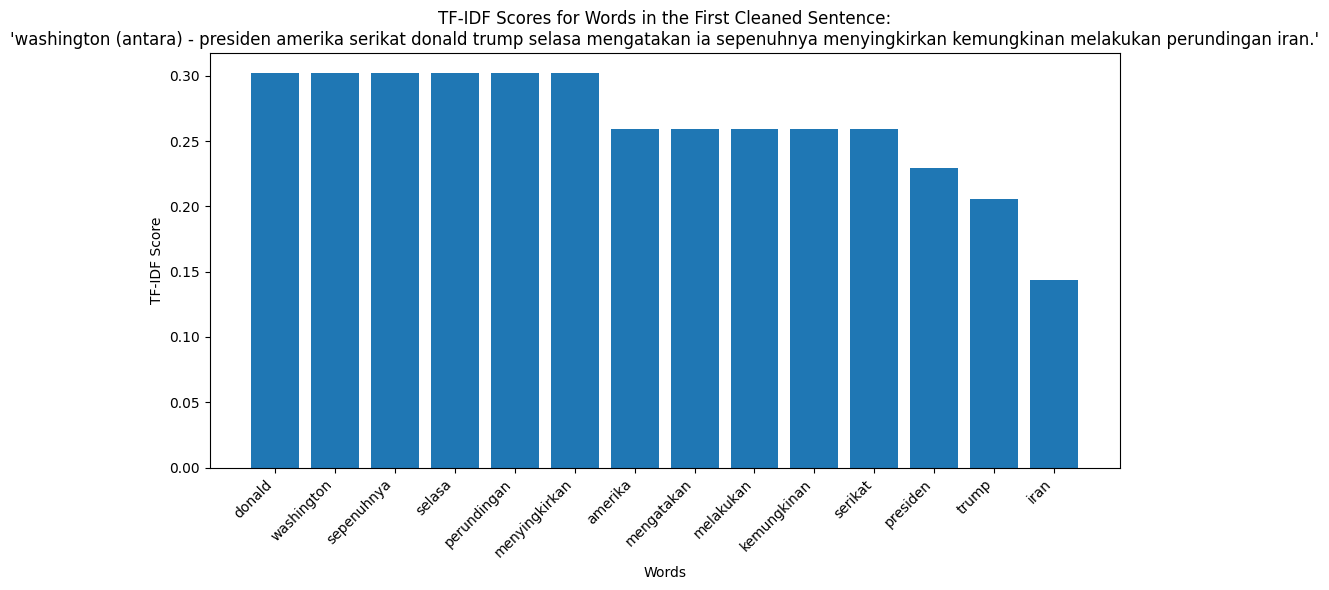

In [14]:
import matplotlib.pyplot as plt

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# Calculate Sentence Score

In [15]:
# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

**List of Sentences:**
1. Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran.
2. “Itu mungkin saja, tergantung pada syaratnya, mungkin saja, hanya mungkin... Anda tahu, sebenarnya kita tidak perlu lagi berbicara, jika benar-benar dipikirkan, tetapi itu mungkin,” kata Trump kepada Fox News ketika ditanya mengenai kemungkinan tersebut.
3. Presiden juga mengatakan bahwa ia tidak percaya Mojtaba Khamenei, putra dari mendiang Ayatollah Ali Khamenei yang telah diangkat sebagai pemimpin tertinggi baru Iran, “dapat hidup dengan damai.” Pada Senin, Trump mengatakan ia “kecewa” dengan terpilihnya Mojtaba Khamenei sebagai pemimpin tertinggi.
4. Pada 28 Februari, Amerika Serikat dan Israel melancarkan serangan terhadap target di Iran, termasuk di Teheran, yang menyebabkan kerusakan serta korban sipil.
5. Iran kemudian membalas dengan menyerang wilayah Israel dan fasilitas mil

In [16]:
# CALCULATE SENTENCE SCORE

sent_scores = []

print("\n=== Average TF-IDF Score for Each Sentence ===")

for i in range(features.shape[0]):

    row = features[i]

    sum_score = row.sum()
    word_count = len(row.data)

    avg_score = sum_score / word_count if word_count > 0 else 0

    sent_scores.append(avg_score)

    print(f"Sentence {i+1}")
    print(" Sum TF-IDF :", sum_score)
    print(" Word Count :", word_count)
    print(" Avg Score  :", avg_score)
    print()

print("Sentence Scores:")
print(sent_scores)


=== Average TF-IDF Score for Each Sentence ===
Sentence 1
 Sum TF-IDF : 3.6891736152624937
 Word Count : 14
 Avg Score  : 0.2635124010901781

Sentence 2
 Sum TF-IDF : 3.492629068332253
 Word Count : 17
 Avg Score  : 0.20544876872542667

Sentence 3
 Sum TF-IDF : 4.157443692383005
 Word Count : 20
 Avg Score  : 0.20787218461915025

Sentence 4
 Sum TF-IDF : 3.8232893063516973
 Word Count : 15
 Avg Score  : 0.2548859537567798

Sentence 5
 Sum TF-IDF : 3.2529513670160193
 Word Count : 11
 Avg Score  : 0.29572285154691086

Sentence 6
 Sum TF-IDF : 4.661522576865444
 Word Count : 22
 Avg Score  : 0.21188738985752018

Sentence 7
 Sum TF-IDF : 3.697715258003644
 Word Count : 14
 Avg Score  : 0.2641225184288317

Sentence 8
 Sum TF-IDF : 3.1178664128987488
 Word Count : 10
 Avg Score  : 0.3117866412898749

Sentence 9
 Sum TF-IDF : 3.1461314492530112
 Word Count : 10
 Avg Score  : 0.3146131449253011

Sentence 10
 Sum TF-IDF : 3.577251273907296
 Word Count : 13
 Avg Score  : 0.27517317491594584

S

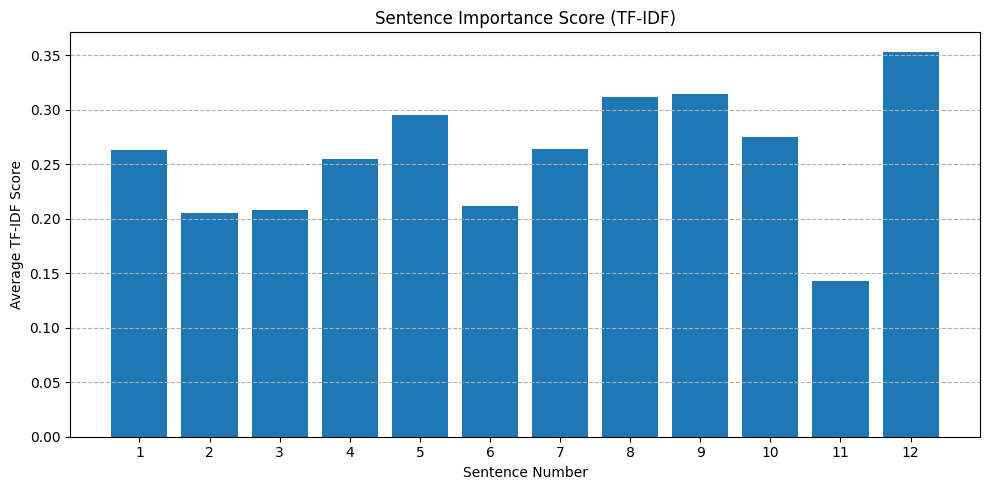


=== Penjelasan Histogram ===
Pada analisis ini, setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). Nilai yang ditampilkan merupakan rata-rata skor TF-IDF pada setiap kalimat.

Histogram di atas menunjukkan perbandingan tingkat kepentingan antar kalimat setelah dilakukan preprocessing teks Bahasa Indonesia (lowercase dan penghapusan stopword menggunakan Sastrawi).

- Sumbu horizontal (Nomor Kalimat): merepresentasikan urutan kalimat dalam berita hasil sentence tokenization.
- Tinggi batang pada setiap kalimat: menunjukkan nilai rata-rata TF-IDF yang merefleksikan seberapa penting kata-kata dalam kalimat tersebut terhadap keseluruhan berita.

Interpretasi nilai batang:
- Batang lebih tinggi → kalimat mengandung kata yang lebih spesifik, jarang muncul, dan informatif sehingga berpotensi menjadi kalimat utama ringkasan.
- Batang lebih rendah → kalimat didominasi kata umum atau informasi pendukung yang kontribu

In [17]:
# VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(range(1, len(sent_scores)+1), sent_scores)

plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Sentence Importance Score (TF-IDF)")

plt.xticks(range(1, len(sent_scores)+1))
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

print("\n=== Penjelasan Histogram ===")

print(
"Pada analisis ini, setiap kalimat dalam berita dihitung tingkat "
"kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). "
"Nilai yang ditampilkan merupakan rata-rata skor TF-IDF pada setiap kalimat."
)

print(
"\nHistogram di atas menunjukkan perbandingan tingkat kepentingan "
"antar kalimat setelah dilakukan preprocessing teks Bahasa Indonesia "
"(lowercase dan penghapusan stopword menggunakan Sastrawi)."
)

print(
"\n- Sumbu horizontal (Nomor Kalimat): "
"merepresentasikan urutan kalimat dalam berita hasil sentence tokenization."
)

print(
"- Tinggi batang pada setiap kalimat: "
"menunjukkan nilai rata-rata TF-IDF yang merefleksikan seberapa penting "
"kata-kata dalam kalimat tersebut terhadap keseluruhan berita."
)

print(
"\nInterpretasi nilai batang:"
)

print(
"- Batang lebih tinggi → kalimat mengandung kata yang lebih spesifik, "
"jarang muncul, dan informatif sehingga berpotensi menjadi kalimat utama ringkasan."
)

print(
"- Batang lebih rendah → kalimat didominasi kata umum atau informasi pendukung "
"yang kontribusinya terhadap inti berita lebih kecil."
)

print(
"\nMelalui histogram ini, kita dapat mengidentifikasi kalimat paling penting "
"yang nantinya dapat dipilih sebagai kandidat ringkasan otomatis berita."
)

# Define Threshold

In [18]:
# DEFINE THRESHOLD FROM SENTENCE SCORES

threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("\n=== Threshold Calculation ===")
print("Threshold (Average Sentence Score):", threshold)


=== Threshold Calculation ===
Threshold (Average Sentence Score): 0.2584649689669258


In [43]:
from nltk.tokenize import word_tokenize
import math

cleaned_sentences = [
    stopword_remover.remove(sentence.lower())
    for sentence in sent_token
]

# TF FUNCTION
def calculate_tf(term, document):
    words = word_tokenize(document)
    return words.count(term) / len(words) if words else 0

# IDF FUNCTION
def calculate_idf(term, documents):

    doc_count = sum(
        1 for doc in documents
        if term in word_tokenize(doc)
    )

    return math.log(len(documents) / doc_count) if doc_count > 0 else 0

# CALCULATE TF-IDF FOR TERM
term = "iran".lower().strip()

idf_value = calculate_idf(term, cleaned_sentences)

tfidf_scores = {}

for i, doc in enumerate(cleaned_sentences):

    tf = calculate_tf(term, doc)
    tfidf = tf * idf_value

    tfidf_scores[f"Sentence {i+1}"] = tfidf

# OUTPUT RESULT
print(f"\nTF-IDF Score untuk kata '{term}':")

for sent, score in tfidf_scores.items():
    print(f"{sent}: {score:.4f}")

print(f"\nOverall IDF '{term}': {idf_value:.4f}")


TF-IDF Score untuk kata 'iran':
Sentence 1: 0.0203
Sentence 2: 0.0000
Sentence 3: 0.0110
Sentence 4: 0.0213
Sentence 5: 0.0338
Sentence 6: 0.0280
Sentence 7: 0.0270
Sentence 8: 0.0369
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0190
Sentence 12: 0.0000

Overall IDF 'iran': 0.4055


In [44]:
# Average of Sentence Scores
threshold = sum(sent_scores)/len(sent_scores)
threshold

np.float64(0.2584649689669258)

# Get Sentences

In [24]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.2584649689669258

**Summary Sentences (above or equal to the threshold):**
- Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran.
- Iran kemudian membalas dengan menyerang wilayah Israel dan fasilitas militer AS di Timur Tengah.
- Pemimpin Tertinggi Iran Ayatollah Ali Khamenei dilaporkan tewas dibunuh pada hari pertama operasi militer tersebut.
- Republik Islam Iran menetapkan masa berkabung nasional selama 40 hari.
- Sementara itu, Presiden Vladimir Putin menggambarkan pembunuhan Khamenei sebagai pelanggaran hukum internasional yang sinis.
- Sementara itu, Kementerian Luar Negeri Rusia mengecam operasi AS-Israel dan menyerukan deeskalasi segera serta penghentian permusuhan.
- Kirim
Komentar menjadi tanggung-jawab Anda sesuai UU ITE.

**Final Summary:**
Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa

In [27]:
# 1. Pecah teks hasil scraping jadi list kalimat
list_kalimat = sent_tokenize(sentence)

# 2. Print dengan format persis seperti di gambar (Kutip dua + koma + enter)
print("sentences = [")
for i, s in enumerate(list_kalimat):
    # Membersihkan karakter aneh seperti \n atau spasi berlebih
    clean_s = s.replace('\n', ' ').strip()

    # Menambahkan koma di akhir kecuali untuk kalimat terakhir
    if i < len(list_kalimat) - 1:
        print(f'    "{clean_s}",')
    else:
        print(f'    "{clean_s}"')
print("]")

sentences = [
    "Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran.",
    "“Itu mungkin saja, tergantung pada syaratnya, mungkin saja, hanya mungkin... Anda tahu, sebenarnya kita tidak perlu lagi berbicara, jika benar-benar dipikirkan, tetapi itu mungkin,” kata Trump kepada Fox News ketika ditanya mengenai kemungkinan tersebut.",
    "Presiden juga mengatakan bahwa ia tidak percaya Mojtaba Khamenei, putra dari mendiang Ayatollah Ali Khamenei yang telah diangkat sebagai pemimpin tertinggi baru Iran, “dapat hidup dengan damai.” Pada Senin, Trump mengatakan ia “kecewa” dengan terpilihnya Mojtaba Khamenei sebagai pemimpin tertinggi.",
    "Pada 28 Februari, Amerika Serikat dan Israel melancarkan serangan terhadap target di Iran, termasuk di Teheran, yang menyebabkan kerusakan serta korban sipil.",
    "Iran kemudian membalas dengan menyerang wilayah Israel dan fasi

In [45]:
sentences = [
    "Presiden Amerika Serikat Donald Trump tidak menutup kemungkinan untuk melakukan perundingan dengan Iran.",
    "Pernyataan tersebut muncul di tengah meningkatnya ketegangan antara kedua negara.",
    "Trump menyebut bahwa peluang dialog tetap terbuka jika kondisi memungkinkan.",
    "Namun, ia juga menegaskan bahwa Amerika Serikat akan tetap bersikap tegas terhadap Iran.",
    "Hubungan antara AS dan Iran mengalami ketegangan dalam beberapa waktu terakhir.",
    "Kedua negara terlibat dalam berbagai konflik kepentingan di kawasan Timur Tengah.",
    "Trump mengatakan bahwa keputusan untuk berunding akan mempertimbangkan berbagai faktor strategis.",
    "Ia juga menekankan pentingnya menjaga stabilitas keamanan global.",
    "Sementara itu, pihak Iran belum memberikan tanggapan resmi terkait pernyataan tersebut.",
    "Para analis menilai bahwa kemungkinan perundingan masih bergantung pada dinamika politik dan diplomasi kedua negara.",
    "Ketegangan antara AS dan Iran telah berdampak pada situasi geopolitik global.",
    "Langkah diplomasi dinilai menjadi salah satu cara untuk meredakan konflik.",
    "Namun, risiko eskalasi tetap ada jika tidak ada kesepakatan yang dicapai.",
    "Pemerintah AS terus memantau perkembangan situasi secara intensif.",
    "Ke depan, hubungan kedua negara diperkirakan masih akan mengalami pasang surut."
]

# Calculate TF-IDF for "iran" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence.lower())
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf(term, cleaned_sentence)
    idf = calculate_idf(term, all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "iran" in each sentence
print("TF-IDF Score for '{term}' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "iran" across all cleaned sentences
overall_idf_iran = calculate_idf(term, all_cleaned_sentences)
print(f"\nOverall IDF for '{term}': {overall_idf_iran:.4f}")

# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    term_index = list(feature_names).index(term)
    print("\nTF-IDF Score for '{term}' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, term_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
  print(f"\nKata '{term}' tidak ditemukan dalam teks artikel setelah pembersihan stopword.")

TF-IDF Score for '{term}' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0630
Sentence 5: 0.0568
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0737
Sentence 10: 0.0000
Sentence 11: 0.0986
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000

Overall IDF for 'iran': 1.0986

TF-IDF Score for '{term}' using TfidfVectorizer:
Sentence 1: 0.2270
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.2737
Sentence 5: 0.2600
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.2445
Sentence 10: 0.0000
Sentence 11: 0.2842
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000


In [46]:
final_summ

' Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran. Iran kemudian membalas dengan menyerang wilayah Israel dan fasilitas militer AS di Timur Tengah. Pemimpin Tertinggi Iran Ayatollah Ali Khamenei dilaporkan tewas dibunuh pada hari pertama operasi militer tersebut. Republik Islam Iran menetapkan masa berkabung nasional selama 40 hari. Sementara itu, Presiden Vladimir Putin menggambarkan pembunuhan Khamenei sebagai pelanggaran hukum internasional yang sinis. Sementara itu, Kementerian Luar Negeri Rusia mengecam operasi AS-Israel dan menyerukan deeskalasi segera serta penghentian permusuhan. Kirim\nKomentar menjadi tanggung-jawab Anda sesuai UU ITE.'

In [47]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran.
-  Iran kemudian membalas dengan menyerang wilayah Israel dan fasilitas militer AS di Timur Tengah.
-  Pemimpin Tertinggi Iran Ayatollah Ali Khamenei dilaporkan tewas dibunuh pada hari pertama operasi militer tersebut.
-  Republik Islam Iran menetapkan masa berkabung nasional selama 40 hari.
-  Sementara itu, Presiden Vladimir Putin menggambarkan pembunuhan Khamenei sebagai pelanggaran hukum internasional yang sinis.
-  Sementara itu, Kementerian Luar Negeri Rusia mengecam operasi AS-Israel dan menyerukan deeskalasi segera serta penghentian permusuhan.
-  Kirim
Komentar menjadi tanggung-jawab Anda sesuai UU ITE.


# Summarization Result

In [48]:
final_summ

' Washington (ANTARA) - Presiden Amerika Serikat Donald Trump pada Selasa mengatakan bahwa ia tidak sepenuhnya menyingkirkan kemungkinan untuk melakukan perundingan dengan Iran. Iran kemudian membalas dengan menyerang wilayah Israel dan fasilitas militer AS di Timur Tengah. Pemimpin Tertinggi Iran Ayatollah Ali Khamenei dilaporkan tewas dibunuh pada hari pertama operasi militer tersebut. Republik Islam Iran menetapkan masa berkabung nasional selama 40 hari. Sementara itu, Presiden Vladimir Putin menggambarkan pembunuhan Khamenei sebagai pelanggaran hukum internasional yang sinis. Sementara itu, Kementerian Luar Negeri Rusia mengecam operasi AS-Israel dan menyerukan deeskalasi segera serta penghentian permusuhan. Kirim\nKomentar menjadi tanggung-jawab Anda sesuai UU ITE.'